Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Using device: cpu
Epoch [1/10], Loss: 1.4314
Epoch [2/10], Loss: 1.0763
Epoch [3/10], Loss: 0.9284
Epoch [4/10], Loss: 0.8305
Epoch [5/10], Loss: 0.7480
Epoch [6/10], Loss: 0.6780
Epoch [7/10], Loss: 0.6129
Epoch [8/10], Loss: 0.5545
Epoch [9/10], Loss: 0.4952
Epoch [10/10], Loss: 0.4448
Accuracy on test data: 70.25%


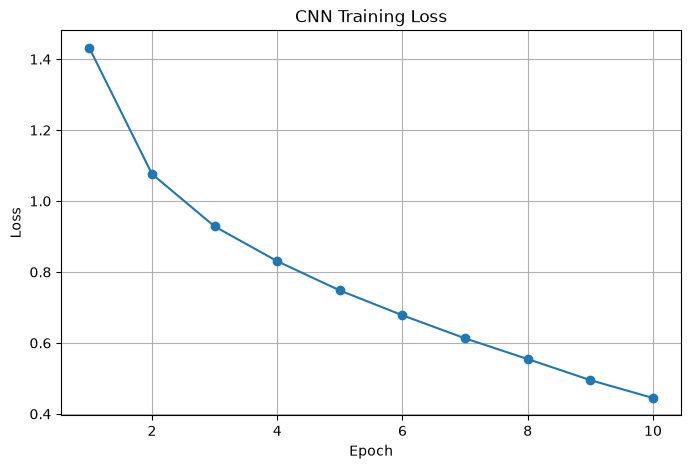

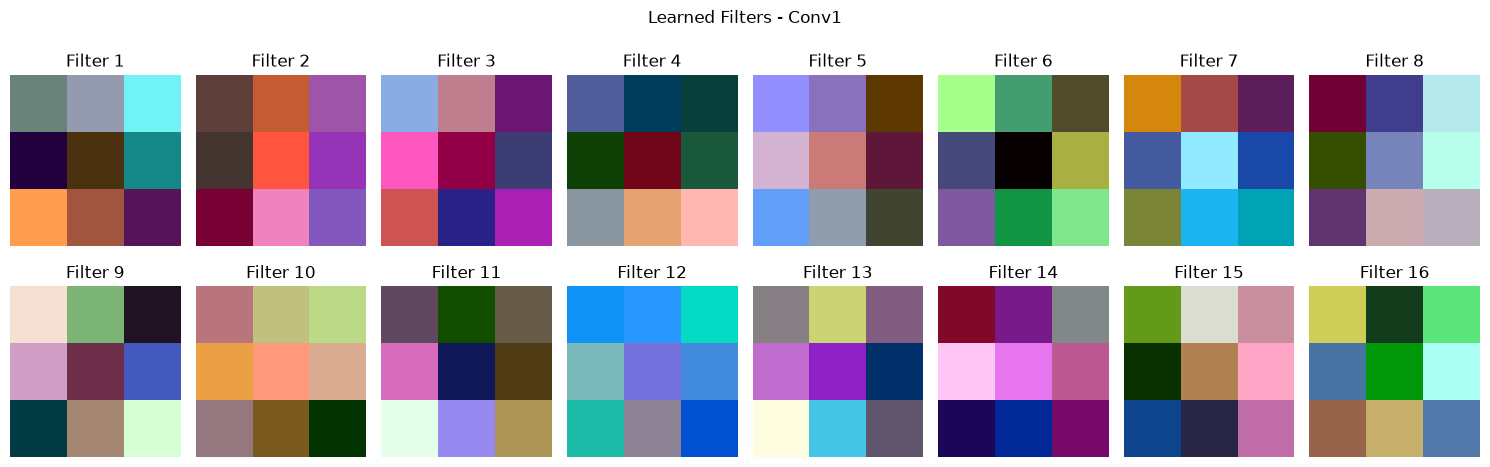

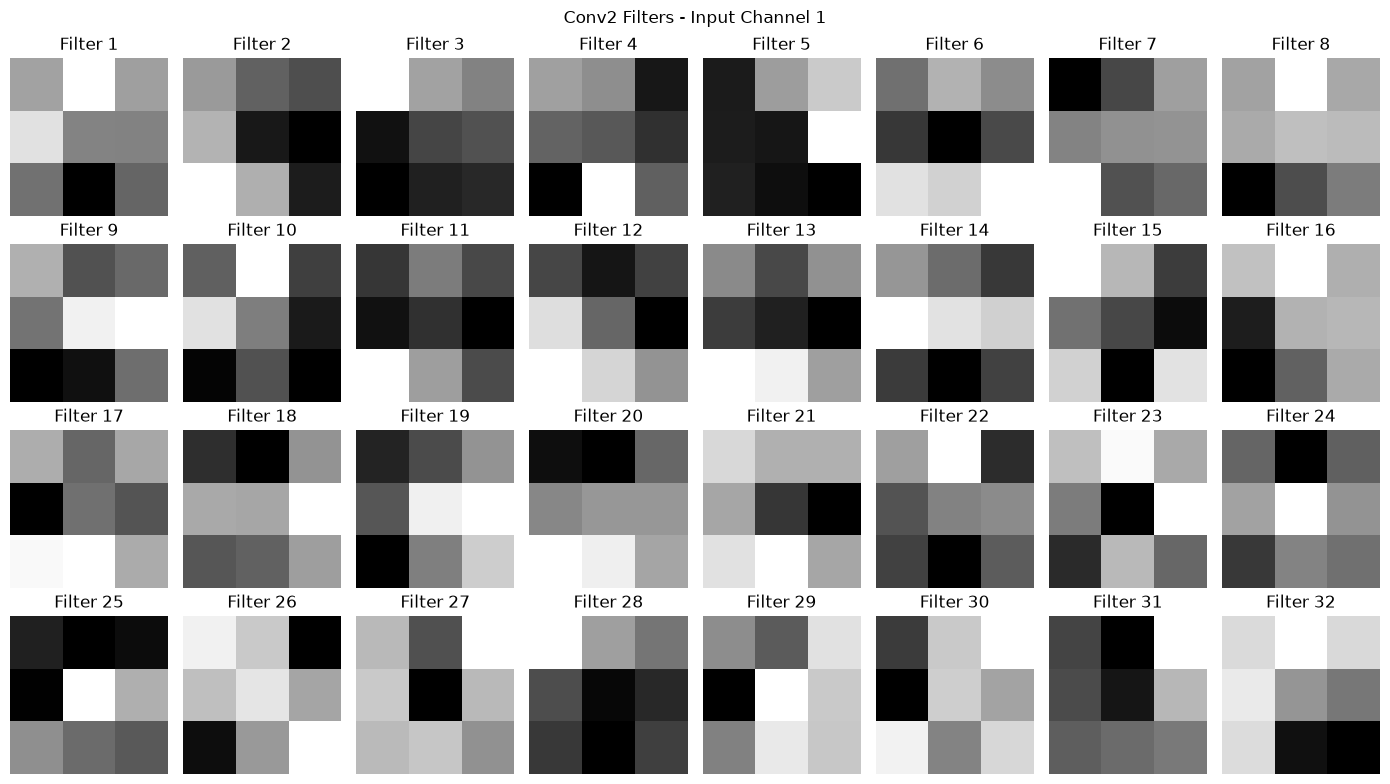

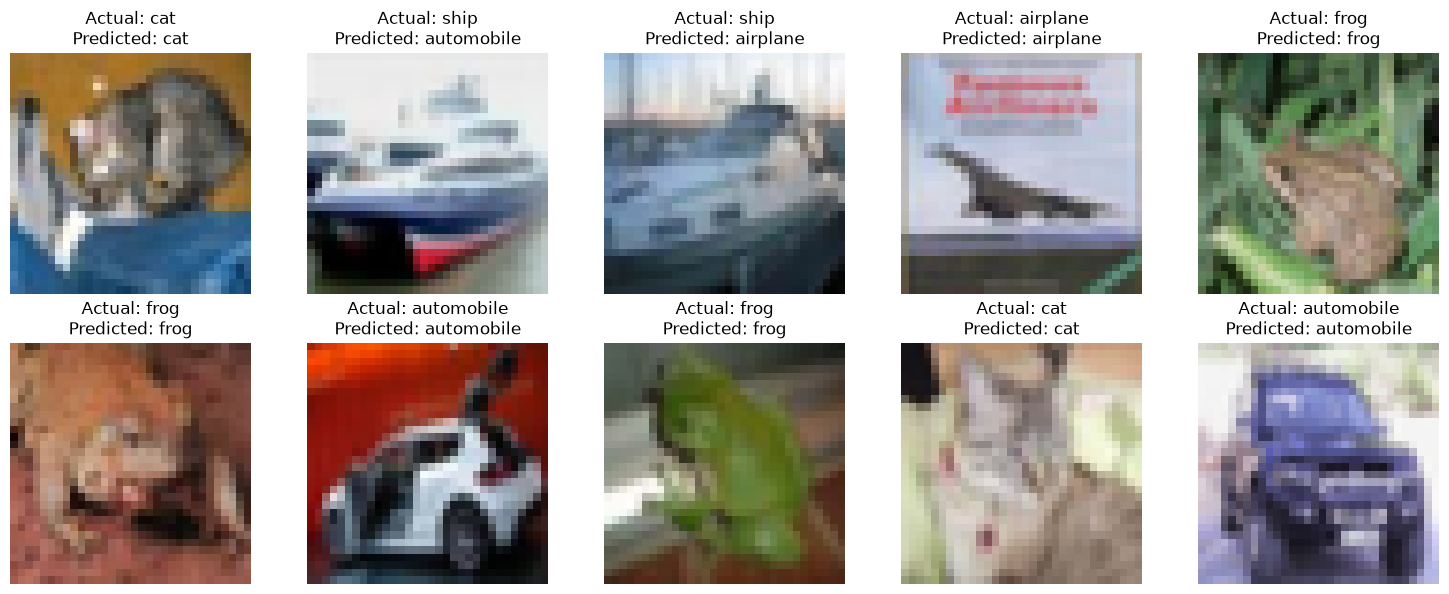

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=0
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=0
)

classes = trainset.classes
print("Classes:", classes)

# Define CNN architecture
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), 32 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = SimpleCNN().to(device)
lossfn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train CNN
epochs = 10
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = lossfn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

# Evaluate model
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy on test data: {accuracy:.2f}%")

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker='o')
plt.title("CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Visualize learned filters in first convolutional layer
filters = model.conv1.weight.detach().cpu()
fig, axs = plt.subplots(2, 8, figsize=(15, 5))

for i, ax in enumerate(axs.flat):
    f = filters[i].permute(1, 2, 0)
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f)
    ax.set_title(f"Filter {i+1}")
    ax.axis("off")

plt.suptitle("Learned Filters - Conv1")
plt.tight_layout()
plt.show()

# Visualize second convolutional layer filters
filters2 = model.conv2.weight.detach().cpu()
fig, axs = plt.subplots(4, 8, figsize=(14, 8))

for i, ax in enumerate(axs.flat):
    f = filters2[i, 0]
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f, cmap='gray')
    ax.set_title(f"Filter {i+1}")
    ax.axis("off")

plt.suptitle("Conv2 Filters - Input Channel 1")
plt.tight_layout()
plt.show()

# Display sample predictions
images, labels = next(iter(testloader))
model.eval()

with torch.no_grad():
    outputs = model(images.to(device))
    _, predicted = torch.max(outputs, 1)

images = images.cpu()
predicted = predicted.cpu()

fig, axs = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axs.flat):
    img = images[i].permute(1, 2, 0) * 0.5 + 0.5
    ax.imshow(img.numpy())
    ax.set_title(
        f"Actual: {classes[labels[i]]}\nPredicted: {classes[predicted[i]]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()